# Portfolio Optimization

**Reference:** Nocedal and Wright, *Numerical Optimization*, 2nd ed. (2006), Example 16.1 (Portfolio Optimization), pp. 449--450.

This notebook is adapted from Problem 3 of Problem Set 3 in [CBE 20258: Numerical and Statistical Analysis](https://ndcbe.github.io/data-and-computing/), where it is used to practice statistical analysis. Here we use it as the course's first **convex** nonlinear program, and as the foil to the circle packing example: same solver, same course, but the answer is guaranteed to be global.


```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 13 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

In [1]:
# This code cell installs packages on Colab

import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
from pyomo.environ import units as u
from pyomo.util.check_units import assert_units_consistent

## The data

Historical daily *adjusted closing prices* for five years (from Yahoo! Finance) are available for the $N = 5$ market indices below. (They are market indices rather than individual stocks, but that does not change the analysis.)

| Symbol | Name |
|-|-|
| DJI | Dow Jones Industrial Average |
| GSPC | S&P 500 |
| IXIC | NASDAQ Composite |
| RUT | Russell 2000 |
| VIX | CBOE Volatility Index |


In [3]:
df_adj_close = pd.read_csv("https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/data/Stock_Data.csv")

print(
    f"{len(df_adj_close)} daily closing prices for {len(df_adj_close.columns)} indices"
)
df_adj_close.head()

1259 daily closing prices for 5 indices


,DJI,GSPC,IXIC,RUT,VIX
0,14447.75000,1551.689941,3235.300049,945.849976,13.74
1,14559.65039,1563.770020,3252.479980,949.820007,12.77
2,14526.16016,1562.849976,3256.520020,950.239990,13.15
3,14578.54004,1569.189941,3267.520020,951.539978,12.70
4,14572.84961,1562.170044,3239.169922,938.789978,13.58


## Step 1. Estimate the model parameters

The one-day return rate for index $i$ between days $t$ and $t+1$ is

$$
r_{t,i} = \frac{p_{t+1,i} - p_{t,i}}{p_{t,i}}
$$

where $p_{t,i}$ is the adjusted closing price. From the matrix of returns $R$ we estimate

* $\bar{r}_i$, the **average** one-day return of index $i$, and
* $\Sigma_r$, the **covariance matrix** of the one-day returns.

Notice that both are *estimated from data*. Neither was given to us. Hold that thought until the last section.


In [4]:
# One-day return rates. pct_change() computes (p_{t+1} - p_t) / p_t.
R = df_adj_close.pct_change().dropna()

# Average one-day return of each index, rbar_i [1/day]
R_avg = R.mean(axis=0)

# Covariance of the one-day returns, Sigma_ij [1/day^2]
Cov = R.cov()

print(f"{len(R)} one-day returns\n")
print("Average one-day return:")
print(R_avg)

1258 one-day returns

Average one-day return:
DJI     0.000432
GSPC    0.000454
IXIC    0.000674
RUT     0.000440
VIX     0.003718
dtype: float64


In [5]:
print("Covariance matrix:")
display(Cov.round(8))

print("\nCorrelation matrix:")
display(R.corr().round(4))

Covariance matrix:


,DJI,GSPC,IXIC,RUT,VIX
DJI,0.000059,0.000058,0.000060,0.000062,-0.000507
GSPC,0.000058,0.000060,0.000066,0.000067,-0.000536
IXIC,0.000060,0.000066,0.000082,0.000080,-0.000596
RUT,0.000062,0.000067,0.000080,0.000101,-0.000609
VIX,-0.000507,-0.000536,-0.000596,-0.000609,0.007374



Correlation matrix:


,DJI,GSPC,IXIC,RUT,VIX
DJI,1.0000,0.9657,0.8658,0.8005,-0.7703
GSPC,0.9657,1.0000,0.9395,0.8615,-0.8037
IXIC,0.8658,0.9395,1.0000,0.8793,-0.7660
RUT,0.8005,0.8615,0.8793,1.0000,-0.7045
VIX,-0.7703,-0.8037,-0.7660,-0.7045,1.0000


## Step 2. The Markowitz mean/variance model

**Given** a set of assets whose returns fluctuate, **choose** what fraction of your money to put in each so that the *variance* of the portfolio return is as small as possible, subject to achieving at least a required expected return.

**Sets.** $\mathcal{S}$ --- the assets.

**Parameters.** $\bar{r}_i$, the expected one-day return of asset $i \in \mathcal{S}$; $\Sigma_r$, the covariance matrix of the one-day returns; $\rho$, the required expected return of the portfolio.

**Variables.** $x_i$, the fraction of funds placed in asset $i$.

$$
\begin{align}
\min_{x} \quad & z := x^T \Sigma_r x && \text{variance of the portfolio return} \\
\text{s.t.} \quad & \bar{r}^T x \geq \rho && \text{achieve the required return} \\
& \sum_{i \in \mathcal{S}} x_i = 1 && \text{invest all of it} \\
& x_i \geq 0 \quad \forall i \in \mathcal{S} && \text{no short selling}
\end{align}
$$

The objective is quadratic and every constraint is linear, so this is a **quadratic program**. Because $\Sigma_r$ is a covariance matrix it is symmetric positive semidefinite, the Hessian of the objective is $2 \Sigma_r$, and the feasible set is an intersection of half-spaces with a hyperplane. The problem is therefore **convex**: every local minimum is a global minimum.


**Units.** The decision variables are *fractions* of the portfolio, so they are
dimensionless; the mean returns are per-day rates and the covariance is per-day-squared.
The builder below declares all three with `units=` and then calls
`assert_units_consistent`, so no model can leave the function without having been
checked. Declaring units and never checking them is worse than not declaring them ---
it looks verified.

In [6]:
def create_portfolio_model(rho, r_avg, cov):
    """Create the Markowitz mean/variance portfolio model in Pyomo

    Arguments:
        rho: required expected return of the portfolio (float)
        r_avg: average one-day return of each asset (pandas Series)
        cov: covariance matrix of the one-day returns (pandas DataFrame)

    Returns:
        m: Pyomo concrete model
    """

    m = pyo.ConcreteModel()

    # Set of assets, S in the notes
    m.ASSETS = pyo.Set(initialize=list(r_avg.index))

    # Required expected return of the portfolio, rho [1/day]
    m.rho = pyo.Param(initialize=rho, mutable=True, units=1 / u.day)

    # Expected one-day return of asset i, rbar_i [1/day]
    m.r_avg = pyo.Param(m.ASSETS, initialize=r_avg.to_dict(), units=1 / u.day)

    # Covariance of the one-day returns, Sigma_ij [1/day^2]
    m.cov = pyo.Param(
        m.ASSETS,
        m.ASSETS,
        initialize={(i, j): cov.loc[i, j] for i in m.ASSETS for j in m.ASSETS},
        units=1 / u.day**2,
    )

    # Funds placed in asset i, x_i [dimensionless]. No short selling, so x_i >= 0.
    m.x = pyo.Var(
        m.ASSETS, domain=pyo.NonNegativeReals, initialize=0.0, units=u.dimensionless
    )

    # Minimize the variance of the portfolio return [1/day^2]
    @m.Objective(sense=pyo.minimize)
    def OBJ(b):
        return sum(b.x[i] * b.cov[i, j] * b.x[j] for i in b.ASSETS for j in b.ASSETS)

    # Achieve at least the required expected return [1/day]
    @m.Constraint()
    def required_return(b):
        return sum(b.r_avg[i] * b.x[i] for i in b.ASSETS) >= b.rho

    # Invest all of it [dimensionless]
    @m.Constraint()
    def budget(b):
        return sum(b.x[i] for i in b.ASSETS) == 1

    # Raises UnitsError if any constraint or the objective is inconsistent
    assert_units_consistent(m)

    return m

## Step 3. Solve

Solve for $\rho = 0.08\%$ per day and report the optimal allocation of funds and the standard deviation of the portfolio return.


In [7]:
rho = 0.0008
m = create_portfolio_model(rho, R_avg, Cov)

solver = pyo.SolverFactory("ipopt")
results = solver.solve(m)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

std_dev = np.sqrt(pyo.value(m.OBJ))
print(f"Standard deviation of the return rate = {std_dev:.6f} per day\n")

print("Optimal allocation of funds:")
for i in m.ASSETS:
    print(f"  {i:>5s}  {pyo.value(m.x[i]) * 100:6.2f}%")

print(
    f"\nExpected return = {sum(pyo.value(m.r_avg[i] * m.x[i]) for i in m.ASSETS):.6f} per day"
)

Standard deviation of the return rate = 0.004580 per day

Optimal allocation of funds:
    DJI   30.55%
   GSPC   18.54%
   IXIC   42.92%
    RUT    0.06%
    VIX    7.93%

Expected return = 0.000800 per day


<div class="admonition note">
<p class="title"><b>Activity</b></p>
 Every constraint in this model is linear and the objective is quadratic. Where, then, is the nonlinearity, and what does it cost you?
</div>


```{dropdown} Click to expand
Entirely in the objective. The feasible set is a polyhedron, so the geometry is as simple as a linear program's. What is *not* simple is that the optimum need not sit at a vertex --- it can sit anywhere in the feasible set. That is why a simplex method will not do, and why we need the more general algorithms in the second half of this course.
```


## Step 4. Sweep $\rho$ --- the efficient frontier

Increasing the required return $\rho$ forces the optimizer to accept more risk. Tracing the trade-off gives the **efficient frontier**: the price of return, paid in variance.


In [8]:
rho_vals = np.arange(0.0005, 0.0038, 0.0001)

rows = []
for rho in rho_vals:
    # Build a fresh model at each rho. Reusing one model warm-starts Ipopt from
    # the previous solution, which shifts the last digit of the answer.
    m_rho = create_portfolio_model(rho, R_avg, Cov)
    results = solver.solve(m_rho)
    assert pyo.check_optimal_termination(results), f"Solve failed at rho = {rho}"
    rows.append(
        [rho, np.sqrt(pyo.value(m_rho.OBJ))]
        + [pyo.value(m_rho.x[i]) for i in m_rho.ASSETS]
    )

frontier = pd.DataFrame(rows, columns=["rho", "std_dev"] + list(m_rho.ASSETS))
display(frontier.round(6))

,rho,std_dev,DJI,GSPC,IXIC,RUT,VIX
0,0.0005,0.004295,0.151414,0.777053,0.000705,0.001233,0.069595
1,0.0006,0.004295,0.153621,0.772839,0.001946,0.001983,0.069611
2,0.0007,0.004314,0.149139,0.714891,0.063419,0.000366,0.072186
3,0.0008,0.004580,0.305530,0.185395,0.429241,0.000561,0.079273
4,0.0009,0.005113,0.176174,0.001217,0.734019,0.000096,0.088495
5,0.0010,0.006011,0.000206,0.000173,0.892248,0.000088,0.107286
6,0.0011,0.007864,0.000067,0.000066,0.859707,0.000049,0.140110
7,0.0012,0.010307,0.000021,0.000023,0.826985,0.000022,0.172950
8,0.0013,0.013010,0.000005,0.000006,0.794188,0.000006,0.205795
9,0.0014,0.015843,0.000029,0.000030,0.761260,0.000028,0.238652


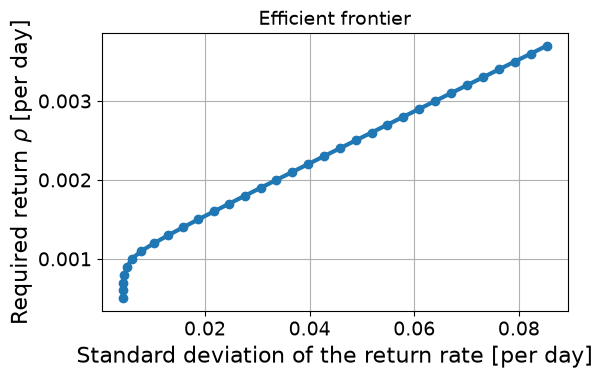

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(frontier["std_dev"], frontier["rho"], "o-")
ax.set_xlabel("Standard deviation of the return rate [per day]")
ax.set_ylabel("Required return $\\rho$ [per day]")
ax.set_title("Efficient frontier")
ax.grid(True)
plt.tight_layout()
plt.show()

### The required return is not always binding

Read the first row of the sweep. The minimum-variance portfolio already returns more per day than $\rho = 0.0005$ demands, so the return constraint is **inactive** at that $\rho$: deleting it would not change the answer. An inequality constraint you wrote down need not cost you a degree of freedom.

This also explains a discrepancy worth knowing about. The problem set this example comes from states the return requirement as an *inequality*, $\bar{r}^T x \geq \rho$, but its solution code writes `== rho`. At $\rho = 0.0008$ the two agree, because the constraint is active. Below the minimum-variance return they do not.


In [10]:
# The minimum-variance portfolio: drop the return requirement entirely.
m_min = create_portfolio_model(0.0, R_avg, Cov)
m_min.required_return.deactivate()
results = solver.solve(m_min)
assert pyo.check_optimal_termination(results), "Solve failed"

min_var_sd = np.sqrt(pyo.value(m_min.OBJ))
min_var_return = sum(pyo.value(m_min.r_avg[i] * m_min.x[i]) for i in m_min.ASSETS)

print(
    f"Minimum-variance portfolio: sd = {min_var_sd:.6f}, return = {min_var_return:.6f} per day"
)
print(
    f"So the constraint rbar^T x >= 0.0005 is inactive ({min_var_return:.6f} > 0.0005)."
)

Minimum-variance portfolio: sd = 0.004297, return = 0.000679 per day
So the constraint rbar^T x >= 0.0005 is inactive (0.000679 > 0.0005).


## Where the data came from

Neither $\bar{r}$ nor $\Sigma_r$ was given to us: both were **estimated** from historical daily returns. They are therefore random variables in their own right, and we can say how uncertain they are. The standard error of a mean estimated from $n$ observations is $s_i / \sqrt{n}$.


In [11]:
se = R.std(axis=0) / np.sqrt(len(R))

summary = pd.DataFrame({"rbar": R_avg, "standard error": se, "ratio": R_avg / se})
display(summary.round(6))

,rbar,standard error,ratio
DJI,0.000432,0.000216,1.995516
GSPC,0.000454,0.000219,2.071757
IXIC,0.000674,0.000255,2.637039
RUT,0.000440,0.000284,1.551509
VIX,0.003718,0.002421,1.535562


Every mean return in the model is known only to within roughly a factor of two of itself. The constraint $\bar{r}^T x \geq \rho$ has *coefficients* that wobble by half their own size --- and we then solved to six significant figures.

**Optimizing a model to a precision its data cannot support is the most common way to be confidently wrong.**

Two caveats on the table above, both of which matter:

1. $s_i / \sqrt{n}$ assumes the daily returns are independent and identically distributed. Financial returns are neither.
2. The standard error is itself an estimate.

Quantifying and then *optimizing under* this kind of uncertainty is what the stochastic programming lectures are for.


## Take away messages

* A quadratic objective with linear constraints is a **quadratic program**. If the Hessian is positive semidefinite the problem is convex, and a local solution is a global solution.
* Contrast with circle packing: same solver, but there the answer depends on where you start, and here it does not.
* An inequality constraint that is **inactive** at the solution costs you nothing. Whether it is active is a property of the solution, not of the model you wrote down.
* Parameters estimated from data carry uncertainty. Report it, or at least know it.
